**Data** **Integration**


Data integration is the process of collecting data from
multiple sources and combining it into one unified dataset
so that it can be analyzed easily.


In [1]:
#concatenation
import pandas as pd
df1 = pd.DataFrame({
    "acc": [1,2,3],
    "name": [0,9,8],
    "age":[34,56,23]
})

In [2]:
df1

,acc,name,age
0,1,0,34
1,2,9,56
2,3,8,23


In [3]:
df2 = pd.DataFrame({
    "acc": [5,9,19],
    "loan": [44,55,3]
})

In [4]:
df2

,acc,loan
0,5,44
1,9,55
2,19,3


In [7]:
row_concat = pd.concat([df1, df2], axis= 0)

In [8]:
row_concat

,acc,name,age,loan
0,1,0.0,34.0,NaN
1,2,9.0,56.0,NaN
2,3,8.0,23.0,NaN
0,5,NaN,NaN,44.0
1,9,NaN,NaN,55.0
2,19,NaN,NaN,3.0


In [9]:
column_concat = pd.concat([df1,df2], axis = 1)

In [10]:
column_concat

,acc,name,age,acc,loan
0,1,0,34,5,44
1,2,9,56,9,55
2,3,8,23,19,3


merge

Merging is the process of combining two or more dataframes based on common columns.

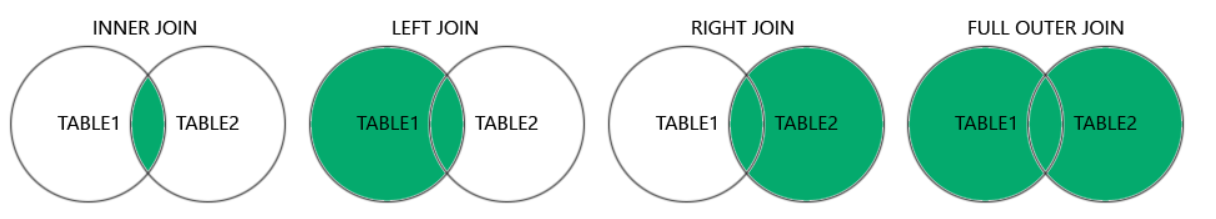

In [13]:
df1 = pd.DataFrame({
    "key": ["E", "B", "C", "Z"],
    "inv_val": [99,55,33,22],
    "acc": [1,2,5,7]
})

In [14]:
df1

,key,inv_val,acc
0,E,99,1
1,B,55,2
2,C,33,5
3,Z,22,7


In [16]:
df2 = pd.DataFrame({
    "key": ["A", "B", "C", "D"],
    "hel_ration": [66, 0.6,45, 76],
    "acc": [11,32,53,74]

})

In [17]:
df2

,key,hel_ration,acc
0,A,66.0,11
1,B,0.6,32
2,C,45.0,53
3,D,76.0,74


In [18]:
pd.merge(df1,df2, how = "inner", on = "key", suffixes = ("_df1", "_df2"))

,key,inv_val,acc_df1,hel_ration,acc_df2
0,B,55,2,0.6,32
1,C,33,5,45.0,53


In [19]:
pd.merge(df1, df2, how = "outer", on = "key", suffixes= ("_df1", "_df2"))

,key,inv_val,acc_df1,hel_ration,acc_df2
0,A,NaN,NaN,66.0,11.0
1,B,55.0,2.0,0.6,32.0
2,C,33.0,5.0,45.0,53.0
3,D,NaN,NaN,76.0,74.0
4,E,99.0,1.0,NaN,NaN
5,Z,22.0,7.0,NaN,NaN


In [20]:
pd.merge(df1, df2, how = "left", on= "key", suffixes = ("_df1", "_df2"))

,key,inv_val,acc_df1,hel_ration,acc_df2
0,E,99,1,NaN,NaN
1,B,55,2,0.6,32.0
2,C,33,5,45.0,53.0
3,Z,22,7,NaN,NaN


In [21]:
pd.merge(df1, df2, how = "right", on = "key", suffixes = ("_df1", "_df2"))

,key,inv_val,acc_df1,hel_ration,acc_df2
0,A,NaN,NaN,66.0,11
1,B,55.0,2.0,0.6,32
2,C,33.0,5.0,45.0,53
3,D,NaN,NaN,76.0,74


In [23]:
pd.merge(df1, df2, how = "cross")

,key_x,inv_val,acc_x,key_y,hel_ration,acc_y
0,E,99,1,A,66.0,11
1,E,99,1,B,0.6,32
2,E,99,1,C,45.0,53
3,E,99,1,D,76.0,74
4,B,55,2,A,66.0,11
5,B,55,2,B,0.6,32
6,B,55,2,C,45.0,53
7,B,55,2,D,76.0,74
8,C,33,5,A,66.0,11
9,C,33,5,B,0.6,32


join in pandas

join xai index ma kaam garxa

Joining is similar to merging, but is specifically used to combine dataframes based on their indexes. You can use the pd.DataFrame.join() method to join dataframes.


In [35]:
df1 = df1.set_index("key")


KeyError: "None of ['key'] are in the columns"

In [32]:
df1

,inv_val,acc
key,,
E,99,1
B,55,2
C,33,5
Z,22,7


In [33]:
df2 = df2.set_index("key")
df2

,hel_ration,acc
key,,
A,66.0,11
B,0.6,32
C,45.0,53
D,76.0,74


In [36]:
df1.join(df2, how ="inner", lsuffix="_x")

,inv_val,acc_x,hel_ration,acc
key,,,,
B,55,2,0.6,32
C,33,5,45.0,53


In [37]:
df2.join(df1, how = "right", rsuffix = "_2")

,hel_ration,acc,inv_val,acc_2
key,,,,
E,NaN,NaN,99,1
B,0.6,32.0,55,2
C,45.0,53.0,33,5
Z,NaN,NaN,22,7


#Stacking

Stacking is the process of vertically combining datasets with the same columns. The datasets are aligned by their column names and then stacked on top of each other. You can use the dataframe.stack() function to stack a dataframe.

In [38]:
df1 = pd.DataFrame(
    {
        "key": ["E","B","C","Z"],
        "inv_val": [99, 55, 33,22],
        "acc": [1,2,5,7]
    }, index=["W","X","Y","Z"]
)

In [39]:
df1

,key,inv_val,acc
W,E,99,1
X,B,55,2
Y,C,33,5
Z,Z,22,7


In [40]:
stacked = df1.stack()
stacked

W  key         E
   inv_val    99
   acc         1
X  key         B
   inv_val    55
   acc         2
Y  key         C
   inv_val    33
   acc         5
Z  key         Z
   inv_val    22
   acc         7
dtype: object

In [41]:
stacked.unstack()

,key,inv_val,acc
W,E,99,1
X,B,55,2
Y,C,33,5
Z,Z,22,7


**Label** **Encoding** **and** **One**
**Hot** **Encoding**

In [42]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [43]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/dsml_pandas/titanic (1).csv")

In [44]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [45]:
# Nominal Data
df["Sex"]

,Sex
0,male
1,female
2,female
3,female
4,male
...,...
886,male
887,female
888,female
889,male


**one** **hot** **encoding**


In [46]:
pd.get_dummies(df, columns=["Sex"], dtype=int)


,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Sex_female,Sex_male
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,S,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,C,1,0
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,S,1,0
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,NaN,S,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",27.0,0,0,211536,13.0000,NaN,S,0,1
887,888,1,1,"Graham, Miss. Margaret Edith",19.0,0,0,112053,30.0000,B42,S,1,0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",NaN,1,2,W./C. 6607,23.4500,NaN,S,1,0
889,890,1,1,"Behr, Mr. Karl Howell",26.0,0,0,111369,30.0000,C148,C,0,1


In [47]:
pd.get_dummies(df, columns=["Embarked"], dtype=int)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,1,0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,0,0,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,0,0,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,0,0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,0,0,1
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,1,0,0


In [48]:
# sklearn

from sklearn.preprocessing import LabelEncoder

In [49]:
label_encode = LabelEncoder()
encode_e = label_encode.fit_transform(df['Embarked'])

In [50]:
encode_e

array([2, 0, 2, 2, 2, 1, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 1, 2, 2, 0, 2, 2,
       1, 2, 2, 2, 0, 2, 1, 2, 0, 0, 1, 2, 0, 2, 0, 2, 2, 0, 2, 2, 0, 0,
       1, 2, 1, 1, 0, 2, 2, 2, 0, 2, 0, 2, 2, 0, 2, 2, 0, 3, 2, 2, 0, 0,
       2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1,
       2, 0, 2, 2, 0, 2, 1, 2, 0, 2, 2, 2, 0, 2, 2, 0, 1, 2, 0, 2, 0, 2,
       2, 2, 2, 0, 2, 2, 2, 0, 0, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 0, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 0, 2,
       2, 0, 2, 2, 2, 0, 2, 2, 2, 2, 1, 2, 1, 2, 2, 2, 2, 2, 0, 0, 1, 2,
       1, 2, 2, 2, 2, 0, 2, 2, 2, 0, 1, 0, 2, 2, 2, 2, 1, 0, 2, 2, 0, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 1,
       2, 2, 0, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2, 0, 2, 1, 2, 2, 2,
       1, 2, 2, 2, 2, 2, 2, 2, 2, 0, 1, 2, 2, 2, 1, 2, 1, 2, 2, 2, 2, 0,
       2, 2, 2, 1, 2, 0, 0, 2, 2, 0, 0, 2, 2, 0, 1,

In [51]:
import numpy as np
encode_e.size

891

In [52]:
label_encode.classes_

array(['C', 'Q', 'S', nan], dtype=object)

In [53]:
label_encode.inverse_transform([0, 1, 3, 2])

array(['C', 'Q', nan, 'S'], dtype=object)

In [54]:
encode_e = label_encode.fit_transform(df['Sex'])

In [55]:
encode_e

array([1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0,
       1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0,